In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve,
    recall_score, precision_score, f1_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # pipeline hỗ trợ SMOTE

In [14]:
df = pd.read_csv("data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# ===========================
# 3. Tiền xử lý cơ bản + chia dữ liệu
# ===========================

# Thay giá trị 0 bằng nan
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)
df[cols_with_zero] = df[cols_with_zero].fillna(df[cols_with_zero].median())

# Tách X, y
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " | Test size:", X_test.shape)


Train size: (614, 8)  | Test size: (154, 8)


In [16]:
# ===========================
# 4. Xây pipeline (Scaler + SMOTE + XGBoost)
# ===========================
pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        scale_pos_weight=1,
        eval_metric='aucpr'
    ))
])

In [17]:
# ===========================
# 5. Stratified K-Fold Cross-validation
# ===========================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recalls, precisions, f1s = [], [], []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_val)

    recalls.append(recall_score(y_val, y_pred))
    precisions.append(precision_score(y_val, y_pred))
    f1s.append(f1_score(y_val, y_pred))

    print(f"Fold {fold}: Recall={recall_score(y_val, y_pred):.3f}, "
          f"Precision={precision_score(y_val, y_pred):.3f}, "
          f"F1={f1_score(y_val, y_pred):.3f}")

print("\n--- Trung bình ---")
print(f"Recall={np.mean(recalls):.3f}, Precision={np.mean(precisions):.3f}, F1={np.mean(f1s):.3f}")


Fold 1: Recall=0.628, Precision=0.659, F1=0.643
Fold 2: Recall=0.698, Precision=0.652, F1=0.674
Fold 3: Recall=0.628, Precision=0.675, F1=0.651
Fold 4: Recall=0.651, Precision=0.583, F1=0.615
Fold 5: Recall=0.619, Precision=0.578, F1=0.598

--- Trung bình ---
Recall=0.645, Precision=0.629, F1=0.636


In [19]:
# ===========================
# 6. Huấn luyện full train + chọn threshold tối ưu recall
# ===========================
pipeline.fit(X_train, y_train)

# Lấy xác suất dự đoán
proba = pipeline.predict_proba(X_test)[:, 1]

# Precision-Recall curve
prec, rec, thr = precision_recall_curve(y_test, proba)
target_recall = 0.9

idx = np.where(rec[:-1] >= target_recall)[0]
if len(idx) > 0:
    best_idx = idx[np.argmax(prec[idx])]
    best_threshold = thr[best_idx]
else:
    best_threshold = 0.4  # fallback nếu không có recall ≥ 0.9

print(f"Threshold được chọn để Recall >= {target_recall}): {best_threshold:.3f}")

Threshold được chọn để Recall >= 0.9): 0.121


Classification report:
               precision    recall  f1-score   support

           0       0.92      0.60      0.73       100
           1       0.55      0.91      0.69        54

    accuracy                           0.71       154
   macro avg       0.74      0.75      0.71       154
weighted avg       0.79      0.71      0.71       154

Confusion matrix:
 [[60 40]
 [ 5 49]]
ROC-AUC: 0.819


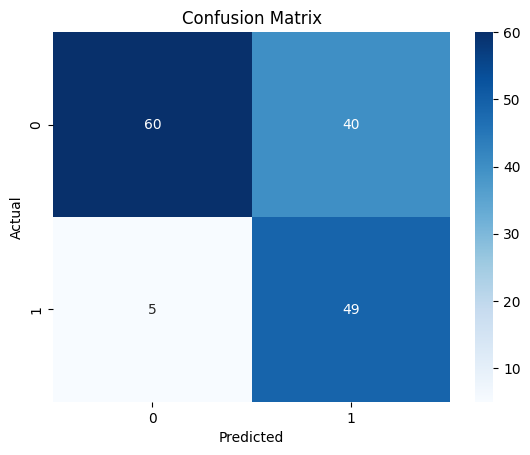

In [21]:
# ===========================
# 7. Đánh giá trên test set
# ===========================
y_pred_custom = (proba >= best_threshold).astype(int)

print("Classification report:\n", classification_report(y_test, y_pred_custom))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_custom))

roc = roc_auc_score(y_test, proba)
print(f"ROC-AUC: {roc:.3f}")

sns.heatmap(confusion_matrix(y_test, y_pred_custom),
            annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

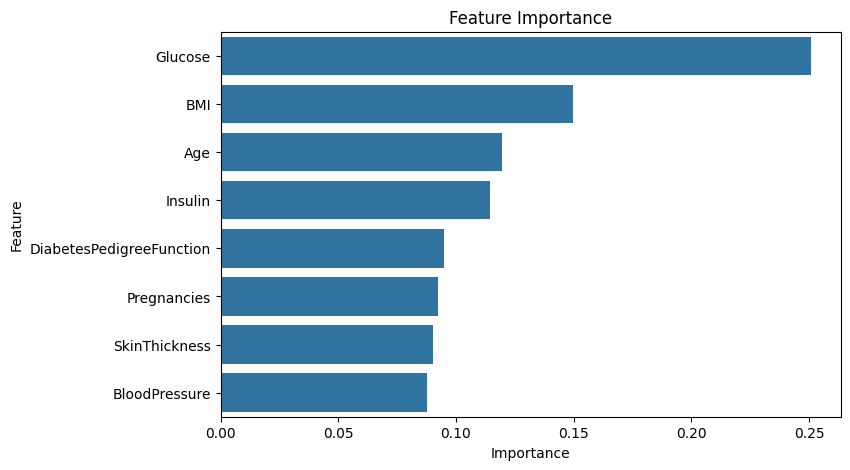

In [23]:
# ===========================
# 8. Feature Importance
# ===========================
final_model = pipeline.named_steps['model']

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()